# First model

The notebook fits one model on the dataset prepared
in `1a_EDA_data_processing` and produces a single score.

The score is not meant to be good. It is the reference and an example for the rest of the week.

## Part 0 - Setup

Run this cell first, in every notebook. It fetches the course repository into
the Colab session and moves into the `notebooks/` folder, so that the
`../data/...` paths work.

It is safe to run more than once, and safe after a restart.

Note: outside Colab the cell does nothing except report the working directory.
Start Jupyter from inside `notebooks/` and the paths work the same way.

If it prints `data ok: True`, you are set.

In [1]:
# --- SETUP: run this first ---  [lares-setup-v1]
# works in Colab and locally, safe to run more than once
import os, sys, subprocess
REPO = "ai_bootcamp_foundations"
if "google.colab" in sys.modules:
    if not os.path.isdir(f"/content/{REPO}"):
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/unizg-fer-lares/{REPO}.git"],
                       cwd="/content", check=True)
    os.chdir(f"/content/{REPO}/notebooks")
print("cwd:", os.getcwd(), "| data ok:", os.path.isdir("../data"))

cwd: C:\Users\novak\Desktop\files\notebooks | data ok: True


In [2]:
import numpy as np, pandas as pd

# same plot styling as in 1a
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt
tex_fonts = {
    "font.family": "serif",
    # Use 26pt font in plots
    "axes.labelsize": 20,
    "font.size": 20,
    "figure.titlesize": 20,
    # Make the legend/label fonts a little smaller
    "legend.title_fontsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
}

plt.rcParams.update(tex_fonts)

## Part 1 - Load the prepared dataset

`1a` saved the train and test split to disk. We reload it instead of splitting
again, so that all results this week refer to the same split.

In [3]:
# load the split saved in 1a
X_train = pd.read_csv("../data/housing_prices/X_train.csv", index_col="Id")
X_test = pd.read_csv("../data/housing_prices/X_test.csv", index_col="Id")
y_train = pd.read_csv("../data/housing_prices/y_train.csv", index_col="Id").squeeze()
y_test = pd.read_csv("../data/housing_prices/y_test.csv", index_col="Id").squeeze()

print('Train dataset size:', X_train.shape[0])
print('Test dataset size:', X_test.shape[0])
print('Features:', list(X_train.columns))

Train dataset size: 1167
Test dataset size: 292
Features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


In [4]:
# target statistics on the training part
y_train.describe()

count      1167.000000
mean     182258.845758
std       80506.602608
min       34900.000000
25%      130125.000000
50%      165000.000000
75%      215000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Part 2 - Baseline, predict the mean

Before fitting anything, predict the training mean for every house. Any model
that does not beat the mean value has learned nothing.

Note: `R2` comes out slightly negative rather than exactly zero, because we use
the mean of the *training* set on the test set.

In [5]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# predict the training mean for every test house
baseline_pred = np.full(len(y_test), y_train.mean())

print('MAE : %10.0f $' % mean_absolute_error(y_test, baseline_pred))
print('RMSE: %10.0f $' % root_mean_squared_error(y_test, baseline_pred))
print('R2  : %10.3f' % r2_score(y_test, baseline_pred))

MAE :      58340 $
RMSE:      75242 $
R2  :     -0.008


### Reading the metrics

- `R2` - share of the variance in price explained by the model: 0 is the mean predictor, 1 is perfect,
- `MAE` - average error in dollars, the number to quote to somebody outside the project,
- `RMSE` - same units, but penalises large errors more, so it is always above MAE.

Whether the error is acceptable depends on what the model is used for. Metric
selection is covered on day 2.

## Part 3 - Linear regression

Create the model, fit it on the training data, predict on the test data.

`fit` sees the training data only. Fitting on anything else makes the test
score meaningless.

In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

print('MAE : %10.0f $' % mean_absolute_error(y_test, pred))
print('RMSE: %10.0f $' % root_mean_squared_error(y_test, pred))
print('R2  : %10.3f' % r2_score(y_test, pred))

MAE :      23905 $
RMSE:      31292 $
R2  :      0.826


In [7]:
# error relative to the price of a house
mae = mean_absolute_error(y_test, pred)
print('MAE                : %10.0f $' % mae)
print('median house price : %10.0f $' % y_test.median())
print('relative error     : %10.1f %%' % (100 * mae / y_test.median()))

MAE                :      23905 $
median house price :     158250 $
relative error     :       15.1 %


## Part 4 - Coefficients

A linear model is readable. Each coefficient is the change in predicted price
for a one-unit increase in that feature, with the others held fixed.

Check the signs before trusting the table.

In [8]:
# coefficients sorted by absolute size
coefs = pd.Series(lr.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print(coefs.round(0).to_string())
print('\nintercept: %.0f' % lr.intercept_)

OverallQual     20426.0
GarageCars      13426.0
FullBath        -5019.0
YearRemodAdd      292.0
YearBuilt         239.0
TotRmsAbvGrd      234.0
GrLivArea          49.0
TotalBsmtSF        18.0
1stFlrSF           17.0
GarageArea          4.0

intercept: -1127005


`FullBath` comes out negative - the model prices an additional bathroom at
about -5000 $. That is not an effect, it is collinearity: bathrooms, living
area and room count move together, and once `GrLivArea` and `TotRmsAbvGrd` are
in the model, the remaining variation in `FullBath` carries little signal.

With correlated features, an individual coefficient is not interpretable on its
own. Regularisation, on day 2, is one response to this.

Note: coefficients are on the raw feature scales. `OverallQual` moves in steps
of 1 on a 1-10 scale, `GrLivArea` in single square feet, so the numbers are not
comparable to each other.

## Part 5 - Residual analysis

One score summarises 292 houses. The residuals show what it hides.

- *predicted vs actual* - points on the diagonal are correct,
- *residuals vs predicted* - structure here means the model is missing something systematic.

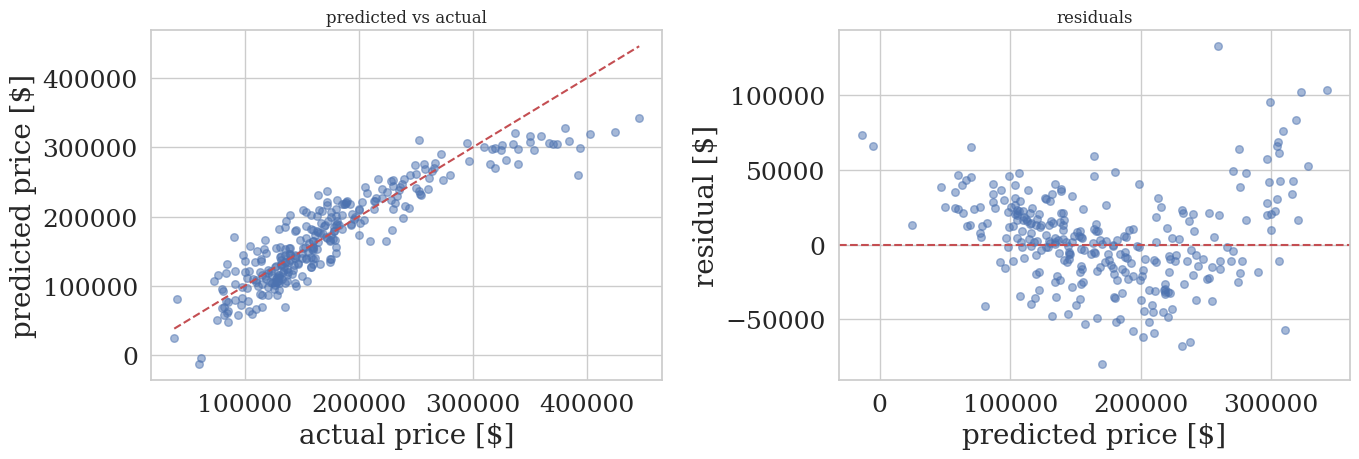

In [9]:
residuals = y_test - pred

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# predicted vs actual
lims = [y_test.min(), y_test.max()]
ax[0].scatter(y_test, pred, alpha=0.5, s=30)
ax[0].plot(lims, lims, 'r--', linewidth=1.5)
ax[0].set_xlabel('actual price [$]')
ax[0].set_ylabel('predicted price [$]')
ax[0].set_title('predicted vs actual')

# residuals
ax[1].scatter(pred, residuals, alpha=0.5, s=30)
ax[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
ax[1].set_xlabel('predicted price [$]')
ax[1].set_ylabel('residual [$]')
ax[1].set_title('residuals')

plt.tight_layout()
plt.show()

Two patterns are visible, and both are predictable from the EDA:

- *expensive houses are underestimated* - the points at the top of the left plot fall below the diagonal, a straight line cannot bend upwards where prices accelerate,
- *residuals fan out with price* - the error grows with the predicted value.

Both are arguments for modelling `log(SalePrice)` instead of `SalePrice`, which
is the first thing tried on day 2.

In [10]:
# the five largest errors
worst = residuals.abs().sort_values(ascending=False).head(5).index
comparison = pd.DataFrame({'actual': y_test[worst],
                           'predicted': pred[[y_test.index.get_loc(i) for i in worst]],
                           'error': residuals[worst]})
comparison.round(0)

,actual,predicted,error
Id,,,
1182,392500,259572.0,132928.0
528,446261,342697.0,103564.0
1143,424870,322910.0,101960.0
1438,394617,298816.0,95801.0
232,403000,319403.0,83597.0


## Part 6 - Record the baseline

This is the output of the notebook. 

In [11]:
print('Ames Housing, linear regression')
print('features: %d' % len(X_train.columns))
print('train: %d houses, test: %d houses' % (len(X_train), len(X_test)))
print('-' * 52)
print('mean predictor   R2 = %6.3f   MAE = %8.0f $' %
      (r2_score(y_test, baseline_pred), mean_absolute_error(y_test, baseline_pred)))
print('linear model     R2 = %6.3f   MAE = %8.0f $' %
      (r2_score(y_test, pred), mean_absolute_error(y_test, pred)))

Ames Housing, linear regression
features: 10
train: 1167 houses, test: 292 houses
----------------------------------------------------
mean predictor   R2 = -0.008   MAE =    58340 $
linear model     R2 =  0.826   MAE =    23905 $


### Conclusions - overall:
- *a baseline that predicts the mean gives R2 near zero and is the floor for every later comparison,*
- *fit on train, score on test, and keep the split fixed for the whole week,*
- *MAE in dollars is the number to report outside the project, R2 is for comparing models,*
- *a single score hides structure - the residual plots showed two problems the R2 did not,*
- *`FullBath` has a negative coefficient because of collinearity, not because bathrooms lower prices,*
- *the target is right-skewed and the residuals fan out, so `log(SalePrice)` is worth testing on day 2,*
- *a linear model scores worse than what comes later, but it can be read.*


_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 1b_First_model_  

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_
